In [123]:
import pandas as pd
import numpy as np

import scipy.stats as stats
from scipy.stats import shapiro, chi2_contingency, mannwhitneyu, kruskal, spearmanr
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, make_scorer

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

import warnings
warnings.filterwarnings('ignore')

from datetime import datetime

In [52]:
# Импортируем старые рассчитаные данные в библиотеку за года по Москве в период панемии
moscow = pd.read_csv('https://raw.githubusercontent.com/JesseHeisenberg/covid_19_statistic/refs/heads/main/Moscow_data_official.csv', sep=';', decimal=',')
moscow.drop('cases.1', axis=1, inplace=True)
moscow.head()

,year,month,cases,death,calculated_death,officcial_death_per_100k,calculated_death_per_100k,cases_per_100k
0,2020,2,817,4,192,0.030534,1.465649,6.236641
1,2020,3,47609,475,-189,3.625954,-1.442748,363.427481
2,2020,4,125071,1775,1904,13.549618,14.534351,954.740458
3,2020,5,46574,1484,5865,11.328244,44.770992,355.526718
4,2020,6,19244,683,3894,5.213740,29.725191,146.900763


In [53]:
def population(row):
    """
    Функция которая добавляет численность насления в 2020-2022 годах.
    """
    if row['year'] == 2020:
        return 12678000
    elif row['year'] == 2021:
        return 12655000
    else:
        return 13015000

Добавлем численность населения по москве за 2020-2022 гг., опираясь на данные Росстата (https://rosstat.gov.ru/)

In [54]:
moscow['population'] = moscow.apply(population, axis=1)
moscow.head(5)

,year,month,cases,death,calculated_death,officcial_death_per_100k,calculated_death_per_100k,cases_per_100k,population
0,2020,2,817,4,192,0.030534,1.465649,6.236641,12678000
1,2020,3,47609,475,-189,3.625954,-1.442748,363.427481,12678000
2,2020,4,125071,1775,1904,13.549618,14.534351,954.740458,12678000
3,2020,5,46574,1484,5865,11.328244,44.770992,355.526718,12678000
4,2020,6,19244,683,3894,5.213740,29.725191,146.900763,12678000


# Проверка на даных на нормальность

In [55]:
# Импортируем данные по абсолютным значениям смертности за все года и разделяем на доковидные / ковидные года
moscow_death_total = pd.read_csv('https://raw.githubusercontent.com/JesseHeisenberg/covid_19_statistic/refs/heads/main/moscow_data.csv', sep=';')
moscow_death_total[['Январь', 'Февраль', 'Март', 'Апрель', 'Май', 'Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь ', 'Декабрь']] = moscow_death_total[['Январь', 'Февраль', 'Март', 'Апрель', 'Май', 'Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь ', 'Декабрь']].astype('float64')
moscow_death_total.columns = ['year', 'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

pre_covid_moscow_death = moscow_death_total[~moscow_death_total['year'].isin([2020, 2021, 2022, 2023, 2024])]
covid_moscow_death = moscow_death_total[moscow_death_total['year'].isin([2020, 2021, 2022])]

covid_moscow_death

,year,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec
14,2020,10913.0,9864.0,10223.0,11834.0,15713.0,13126.0,10771.0,10972.0,11153.0,13710.0,14456.0,16546.0
15,2021,16347.0,12658.0,13213.0,12803.0,13705.0,16406.0,17334.0,12753.0,11855.0,14727.0,16553.0,14481.0
16,2022,14376.0,14496.0,11551.0,9144.0,9345.0,8914.0,8384.0,9755.0,10008.0,9703.0,10008.0,11304.0


In [56]:
def shapiro_calculations(df):
    """
    Функция принимает на вход датафрем и определяет номрмальность распределения данных по смертности по каждому месяцу за несколько лет.
    Т.е. поступают данные по смретности за каждый месяц в течении нескольких лет

    На выход в случае нормальности распредления данных получаем занчения статистики и p-значения.
    Если наблюдается ненормальное распредление, дополнительно выводим график для наглядности
    """
    for month in df.columns:
        if month == 'year':
            continue

        stat, pval = shapiro(df[month])

        if pval > 0.05:
            print(month.upper())
            print('Данные распредлены нормально')
            print(f'Statistic: {stat:.5f}, pval: {pval:.5f}')

        else:
            print(month.upper())
            print('Данныке НЕ распределены нормально')
            print(f'Statistic: {stat:.5f}, pval: {pval:.5f}')
            sns.kdeplot(df[month])
            plt.show()

        print('-'*20)

JAN
Данные распредлены нормально
Statistic: 0.89295, pval: 0.08915
--------------------
FEB
Данные распредлены нормально
Statistic: 0.90334, pval: 0.12609
--------------------
MAR
Данные распредлены нормально
Statistic: 0.87744, pval: 0.05344
--------------------
APR
Данные распредлены нормально
Statistic: 0.93719, pval: 0.38355
--------------------
MAY
Данные распредлены нормально
Statistic: 0.91146, pval: 0.16550
--------------------
JUN
Данные распредлены нормально
Statistic: 0.96778, pval: 0.84562
--------------------
JUL
Данныке НЕ распределены нормально
Statistic: 0.48837, pval: 0.00000


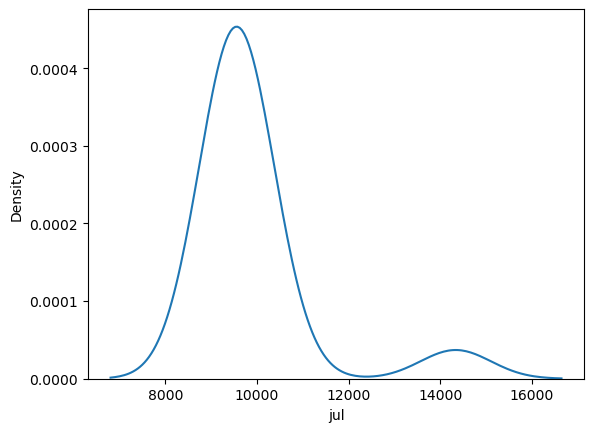

--------------------
AUG
Данныке НЕ распределены нормально
Statistic: 0.52567, pval: 0.00001


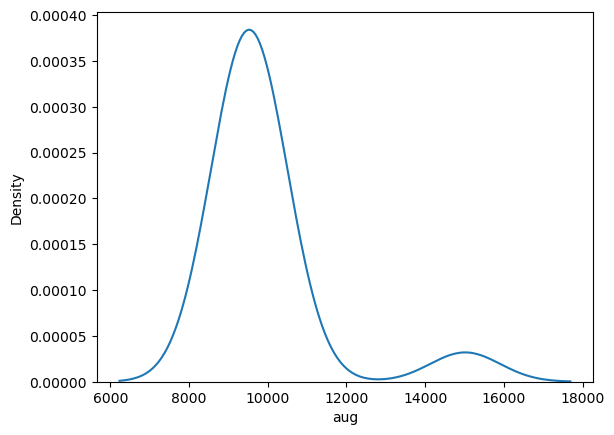

--------------------
SEP
Данные распредлены нормально
Statistic: 0.91081, pval: 0.16189
--------------------
OCT
Данные распредлены нормально
Statistic: 0.88911, pval: 0.07849
--------------------
NOV
Данные распредлены нормально
Statistic: 0.97619, pval: 0.94664
--------------------
DEC
Данные распредлены нормально
Statistic: 0.88495, pval: 0.06838
--------------------


In [57]:
# Применяем функцию выше для смертности доковидынх годов
shapiro_calculations(pre_covid_moscow_death)

----------------

# Первичная обработка данных / поиск выбросов и их удаление

In [58]:
"""Нахожу выбросы, которые находятся выше/ниже 3-х межквартильных занчений, т.к.
в дальнейшем я буду рабоатать со средними, поэтому на этом этапе принимаю решение избавиться от таких выбросов
"""
pre_covid_outlers_list = {}

for month in pre_covid_moscow_death.columns:
    if month == 'year':
        continue

    iqr = pre_covid_moscow_death[month].quantile(0.75) - pre_covid_moscow_death[month].quantile(0.25)
    upper_bound = pre_covid_moscow_death[month].quantile(0.75) + 3 * iqr
    lower_bound = pre_covid_moscow_death[month].quantile(0.25) - 3 * iqr
    outlers = [x for x in pre_covid_moscow_death[month] if x > upper_bound or x < lower_bound]

    pre_covid_outlers_list[month] = outlers

pre_covid_outlers_list

{'jan': [],
 'feb': [],
 'mar': [],
 'apr': [],
 'may': [],
 'jun': [],
 'jul': [14340.0],
 'aug': [15016.0],
 'sep': [],
 'oct': [9350.0],
 'nov': [],
 'dec': []}

In [59]:
# Удаляем выбросы
jul_max, jul_median = pre_covid_moscow_death['jul'].max(), pre_covid_moscow_death['jul'].median()
aug_max, aug_median = pre_covid_moscow_death['aug'].max(), pre_covid_moscow_death['aug'].median()


pre_covid_moscow_death['aug'].replace(aug_max, aug_median, inplace=True)
pre_covid_moscow_death['jul'].replace(jul_max, jul_median, inplace=True)

# Итоговая проверка на нормальность распредления - графиков нетЮ считаем что данные теперь распределны нормально
shapiro_calculations(pre_covid_moscow_death)

JAN
Данные распредлены нормально
Statistic: 0.89295, pval: 0.08915
--------------------
FEB
Данные распредлены нормально
Statistic: 0.90334, pval: 0.12609
--------------------
MAR
Данные распредлены нормально
Statistic: 0.87744, pval: 0.05344
--------------------
APR
Данные распредлены нормально
Statistic: 0.93719, pval: 0.38355
--------------------
MAY
Данные распредлены нормально
Statistic: 0.91146, pval: 0.16550
--------------------
JUN
Данные распредлены нормально
Statistic: 0.96778, pval: 0.84562
--------------------
JUL
Данные распредлены нормально
Statistic: 0.93123, pval: 0.31751
--------------------
AUG
Данные распредлены нормально
Statistic: 0.94328, pval: 0.46195
--------------------
SEP
Данные распредлены нормально
Statistic: 0.91081, pval: 0.16189
--------------------
OCT
Данные распредлены нормально
Statistic: 0.88911, pval: 0.07849
--------------------
NOV
Данные распредлены нормально
Statistic: 0.97619, pval: 0.94664
--------------------
DEC
Данные распредлены нормально

In [60]:
# Датафрейм для наглядности
pre_covid_moscow_death.head(5)

,year,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec
0,2006,11814.0,10291.0,11545.0,9951.0,10817.0,10427.0,9661.0,10071.0,10277.0,10939.0,10627.0,10622.0
1,2007,11644.0,10015.0,11036.0,10213.0,10889.0,9606.0,9644.0,10098.0,9595.0,10837.0,10350.0,10403.0
2,2008,11622.0,10151.0,10965.0,10558.0,10411.0,9840.0,10062.0,9472.0,10396.0,10501.0,9502.0,10824.0
3,2009,11186.0,9956.0,10660.0,10185.0,9548.0,9598.0,9516.0,8905.0,9476.0,10613.0,9923.0,10547.0
4,2010,10430.0,9573.0,10528.0,9591.0,9482.0,9529.0,9579.5,9539.0,9573.0,9350.0,9091.0,9664.0


 # Добавление числености населения в допандеймийные года

In [61]:
# Создаю датафрейм с населением москвы за каждый год
year = list(range(2006, 2023))
population = np.array([10923, 11091, 11186, 11281, 11504, 11541, 11613, 11979, 12108, 12198, 12330, 12381, 12506, 12615, 12678, 12655, 13015]) * 1000 # Изначальные данные на 1000 чел., поэтому привожу их к абсолютным занчениям
population_by_year_moscow = pd.DataFrame({
    'year': year,
    'population': population
})

# Джойним значение населения из датафрейма выше
pre_covid_moscow_death = pre_covid_moscow_death.merge(population_by_year_moscow, on='year', how='inner')
covid_moscow_death = covid_moscow_death.merge(population_by_year_moscow, on='year', how='inner')
pre_covid_moscow_death

,year,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec,population
0,2006,11814.0,10291.0,11545.0,9951.0,10817.0,10427.0,9661.0,10071.0,10277.0,10939.0,10627.0,10622.0,10923000
1,2007,11644.0,10015.0,11036.0,10213.0,10889.0,9606.0,9644.0,10098.0,9595.0,10837.0,10350.0,10403.0,11091000
2,2008,11622.0,10151.0,10965.0,10558.0,10411.0,9840.0,10062.0,9472.0,10396.0,10501.0,9502.0,10824.0,11186000
3,2009,11186.0,9956.0,10660.0,10185.0,9548.0,9598.0,9516.0,8905.0,9476.0,10613.0,9923.0,10547.0,11281000
4,2010,10430.0,9573.0,10528.0,9591.0,9482.0,9529.0,9579.5,9539.0,9573.0,9350.0,9091.0,9664.0,11504000
5,2011,10335.0,9219.0,10067.0,9483.0,9424.0,8801.0,9111.0,9476.0,9325.0,9830.0,9692.0,9660.0,11541000
6,2012,10354.0,10010.0,10317.0,9695.0,9690.0,9167.0,9193.0,9184.0,9233.0,10493.0,9577.0,10576.0,11613000
7,2013,11184.0,9396.0,10084.0,9894.0,9724.0,8520.0,9384.0,9261.0,9210.0,10143.0,9434.0,9967.0,11979000
8,2014,10311.0,9235.0,10256.0,9884.0,10219.0,8924.0,9547.0,9054.0,9821.0,10315.0,9042.0,10783.0,12108000
9,2015,11042.0,10146.0,10886.0,10271.0,9742.0,9639.0,9612.0,9476.0,9815.0,10554.0,9962.0,10809.0,12198000


# Пресчет методолгии среднее смертности в доковидные года

Ранее расчитывали значения по смертности на 100к насления относительно средней численности за 2020-2022 гг.

Сейчас считаем смертсноть на 100к по формуле месяц_год / численность_год. Затем считаем среднее значение по каждому из месяцу, например
(декабрь_2006 + ... + декабрь_2019) / кол-во лет


In [62]:
# Копия датафрейма для дальнейшей обработки
pre_covid_moscow_death_ = pre_covid_moscow_death.copy()
pre_covid_moscow_death_.head()

,year,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec,population
0,2006,11814.0,10291.0,11545.0,9951.0,10817.0,10427.0,9661.0,10071.0,10277.0,10939.0,10627.0,10622.0,10923000
1,2007,11644.0,10015.0,11036.0,10213.0,10889.0,9606.0,9644.0,10098.0,9595.0,10837.0,10350.0,10403.0,11091000
2,2008,11622.0,10151.0,10965.0,10558.0,10411.0,9840.0,10062.0,9472.0,10396.0,10501.0,9502.0,10824.0,11186000
3,2009,11186.0,9956.0,10660.0,10185.0,9548.0,9598.0,9516.0,8905.0,9476.0,10613.0,9923.0,10547.0,11281000
4,2010,10430.0,9573.0,10528.0,9591.0,9482.0,9529.0,9579.5,9539.0,9573.0,9350.0,9091.0,9664.0,11504000


In [63]:
# расчет приведенной смертности помесячно за каждый год
for month in pre_covid_moscow_death_.iloc[:, 1:-1].columns:
    pre_covid_moscow_death_[f'{month}'] = pre_covid_moscow_death_.apply(lambda x: x[month] / x['population'] * 100000, axis=1)

pre_covid_moscow_death_.head()

,year,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec,population
0,2006,108.157100,94.214044,105.694406,91.101346,99.029571,95.459123,88.446398,92.199945,94.085874,100.146480,97.290122,97.244347,10923000
1,2007,104.986025,90.298440,99.504102,92.083671,98.178703,86.610765,86.953386,91.046795,86.511586,97.709855,93.318907,93.796772,11091000
2,2008,103.897729,90.747363,98.024316,94.385839,93.071697,87.967102,89.951725,84.677275,92.937601,93.876274,84.945468,96.763812,11186000
3,2009,99.157876,88.254587,94.495169,90.284549,84.637887,85.081110,84.354224,78.938037,83.999645,94.078539,87.962060,93.493485,11281000
4,2010,90.664117,83.214534,91.515994,83.371001,82.423505,82.832058,83.271036,82.918985,83.214534,81.276078,79.024687,84.005563,11504000


In [64]:
# Расчет среднего значения помесячно за все доковидные года
avg_monthly_death = pre_covid_moscow_death_.mean().to_frame().T
avg_monthly_death.drop(columns=['year', 'population'], inplace=True)
avg_monthly_death = avg_monthly_death.round(5)

avg_monthly_death

,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec
0,94.73608,83.15415,90.0943,84.82399,84.83352,80.16713,81.17487,80.93637,81.87445,88.27846,82.92448,88.80939


In [65]:
avg_monthly_death.values

array([[94.73608, 83.15415, 90.0943 , 84.82399, 84.83352, 80.16713,
        81.17487, 80.93637, 81.87445, 88.27846, 82.92448, 88.80939]])

# Работа со смертностью в перод пандемии

In [66]:
covid_moscow_death_ = covid_moscow_death.copy().reset_index()
covid_moscow_death_.drop(columns='index', inplace=True, axis=1)
covid_moscow_death_

,year,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec,population
0,2020,10913.0,9864.0,10223.0,11834.0,15713.0,13126.0,10771.0,10972.0,11153.0,13710.0,14456.0,16546.0,12678000
1,2021,16347.0,12658.0,13213.0,12803.0,13705.0,16406.0,17334.0,12753.0,11855.0,14727.0,16553.0,14481.0,12655000
2,2022,14376.0,14496.0,11551.0,9144.0,9345.0,8914.0,8384.0,9755.0,10008.0,9703.0,10008.0,11304.0,13015000


In [67]:
for month in covid_moscow_death_.iloc[:, 1:-1].columns:
    covid_moscow_death_[f'{month}'] = covid_moscow_death_.apply(lambda x: x[month] / x['population'] * 100000, axis=1)
covid_moscow_death_ = covid_moscow_death_.round(5)

In [68]:
avg_monthly_death

,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec
0,94.73608,83.15415,90.0943,84.82399,84.83352,80.16713,81.17487,80.93637,81.87445,88.27846,82.92448,88.80939


In [69]:
columns_to_keep = [col for col in covid_moscow_death_.columns if col not in ['year', 'population']]
df_2020 = covid_moscow_death_[covid_moscow_death_['year'] == 2020][columns_to_keep]
df_2021 = covid_moscow_death_[covid_moscow_death_['year'] == 2021][columns_to_keep].reset_index().drop('index', axis=1)
df_2022 = covid_moscow_death_[covid_moscow_death_['year'] == 2022][columns_to_keep].reset_index().drop('index', axis=1)

df_2020 = df_2020 - avg_monthly_death
df_2021 = df_2021 - avg_monthly_death
df_2022 = df_2022 - avg_monthly_death

covid_cummaulative_mortality = pd.concat([df_2020, df_2021, df_2022]).reset_index().drop('index', axis=1)
covid_cummaulative_mortality['year'] = [2020, 2021, 2022]

covid_cummaulative_mortality = (pd.DataFrame(covid_cummaulative_mortality.stack())
 .reset_index()
 .rename(columns={'level_0': 'year', 'level_1':'month', 0: 'death_per_100k_V2'}, )
)

covid_cummaulative_mortality['year'] = covid_cummaulative_mortality['year'].apply(lambda x: 2020 if x == 0 else x)
covid_cummaulative_mortality['year'] = covid_cummaulative_mortality['year'].apply(lambda x: 2021 if x == 1 else x)
covid_cummaulative_mortality['year'] = covid_cummaulative_mortality['year'].apply(lambda x: 2022 if x == 2 else x)

month_dict = {
    'jan': 1,
    'feb': 2,
    'mar': 3,
    'apr': 4,
    'may': 5,
    'jun': 6,
    'jul': 7,
    'aug': 8,
    'sep': 9,
    'oct': 10,
    'nov': 11,
    'dec': 12
}

covid_cummaulative_mortality['month'] = covid_cummaulative_mortality['month'].map(month_dict)
covid_cummaulative_mortality.dropna(inplace=True)

covid_cummaulative_mortality['month'] = covid_cummaulative_mortality['month'].astype('int64')
covid_cummaulative_mortality = pd.merge(covid_cummaulative_mortality, moscow[['year', 'month', 'officcial_death_per_100k', 'calculated_death_per_100k']], on=['year', 'month'], how='left')
covid_cummaulative_mortality.dropna(inplace=True)

covid_cummaulative_mortality

,year,month,death_per_100k_V2,officcial_death_per_100k,calculated_death_per_100k
1,2020,2,-5.35008,0.030534,1.465649
2,2020,3,-9.45855,3.625954,-1.442748
3,2020,4,8.51881,13.549618,14.534351
4,2020,5,39.10559,11.328244,44.770992
5,2020,6,23.36655,5.213740,29.725191
6,2020,7,3.78333,2.786260,9.793893
7,2020,8,5.60725,3.007634,11.358779
8,2020,9,6.09684,10.671756,12.526718
9,2020,10,19.86163,16.625954,25.519084
10,2020,11,31.09981,17.045802,36.412214


# Строим графики для сравнения трех показателей
1. Официальные данные по смертности
2. Избыточная смертность V1 - данные по избыточной смертности по диплому
3. Избыточная смертность V2 - пересчитанные по новой логике данные по избыточной смертности

Данные приведены к 100к населения

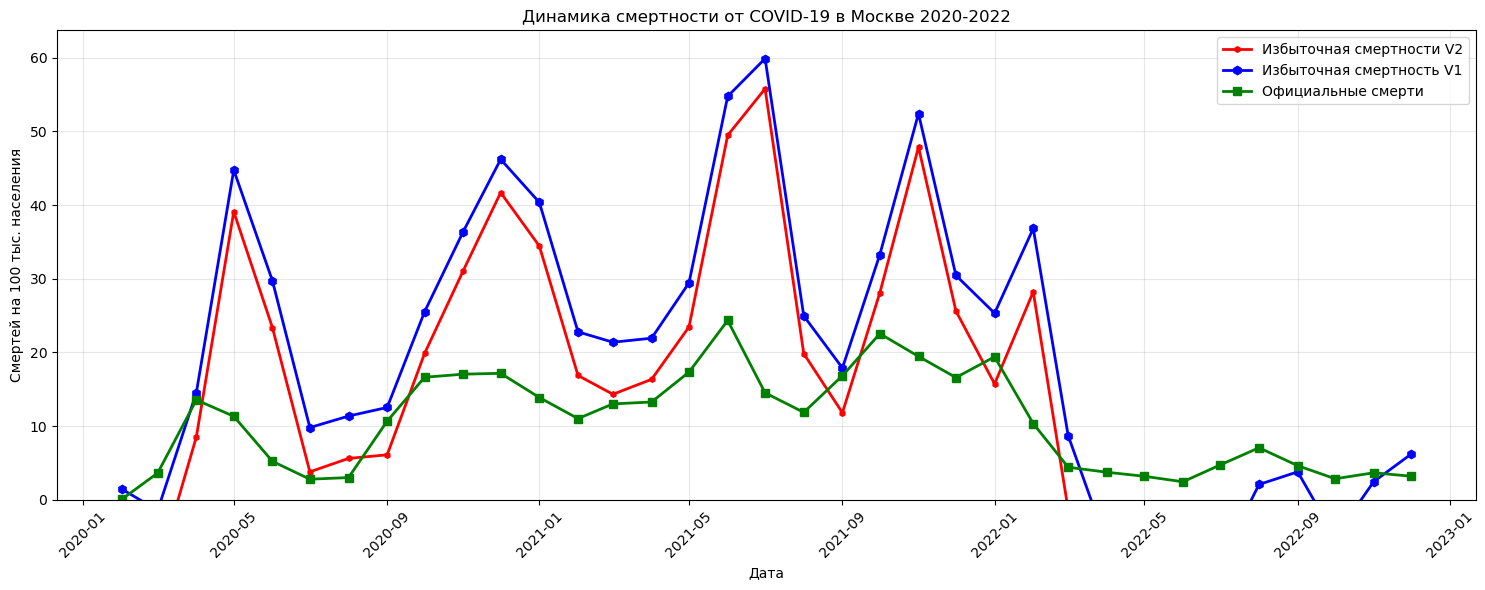

In [70]:
covid_cummaulative_mortality['date'] = pd.to_datetime(
    covid_cummaulative_mortality['year'].astype(str) + '-' +
    covid_cummaulative_mortality['month'].astype(str) + '-01'
)

covid_cummaulative_mortality = covid_cummaulative_mortality.sort_values('date')

start_date = '2020-02-01'
end_date = '2022-12-31'
continuous_df = covid_cummaulative_mortality[
    (covid_cummaulative_mortality['date'] >= start_date) &
    (covid_cummaulative_mortality['date'] <= end_date)
]

moscow['date'] = pd.to_datetime(moscow['year'].astype(str) + '-' + moscow['month'].astype(str) + '-01')
moscow = moscow.sort_values('date')
filtered_df = moscow[(moscow['date'] >= '2020-02-01') & (moscow['date'] <= '2022-12-31')]

plt.figure(figsize=(15, 6))
plt.plot(continuous_df['date'], continuous_df['death_per_100k_V2'], color='red', marker='h', linewidth=2, markersize=4, label='Избыточная смертности V2')
plt.plot(filtered_df['date'], filtered_df['calculated_death_per_100k'], color='blue', marker='h', linewidth=2, label='Избыточная смертность V1')
plt.plot(filtered_df['date'], filtered_df['officcial_death_per_100k'], color='green', marker='s', linewidth=2, label='Официальные смерти')
plt.xlabel('Дата')
plt.ylabel('Смертей на 100 тыс. населения')
plt.title('Динамика смертности от COVID-19 в Москве 2020-2022')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

In [71]:
covid_cummaulative_mortality.drop(columns='date', inplace=True)

# Расчет статистических показателей

In [72]:
stat, pval = stats.spearmanr(covid_cummaulative_mortality['death_per_100k_V2'], covid_cummaulative_mortality['officcial_death_per_100k'])
if pval < 0.05:
    print('Корреляция статистически значима')
else:
    print('Нет статистической значимости')
print(f'Satistic: {stat}')

Корреляция статистически значима
Satistic: 0.7837535014005603


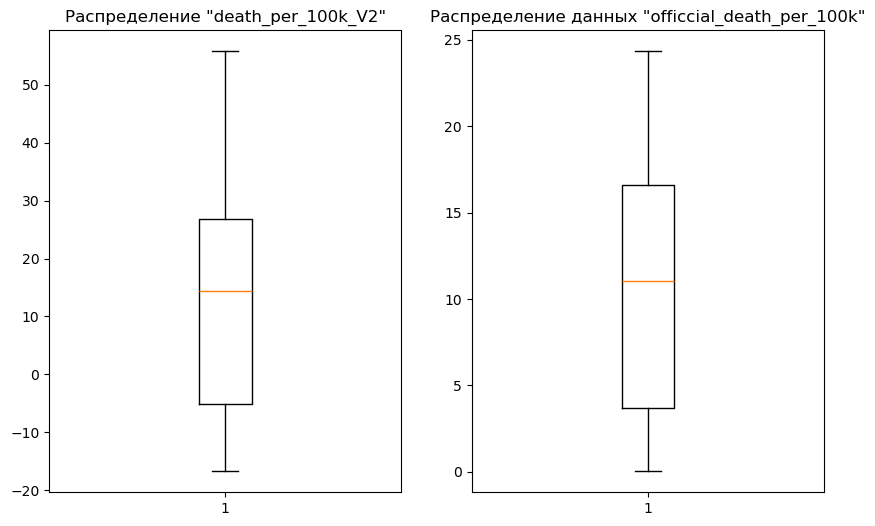

In [110]:
# Сравнение распредление данных официальной статистики и избытка смертности в V2

fig, ax = plt.subplots(1, 2, figsize=(10, 6))

ax[0].boxplot(covid_cummaulative_mortality['death_per_100k_V2'], label='death_per_100k_V2')
ax[0].set_title('Распределение "death_per_100k_V2"')

ax[1].boxplot(covid_cummaulative_mortality['officcial_death_per_100k'], label='officcial_death_per_100k')
ax[1].set_title('Распределение данных "officcial_death_per_100k"')

plt.show()

In [106]:
# Избавлаяемся от нулевых и минусовых значений в рассчетах
vied_period = covid_cummaulative_mortality[covid_cummaulative_mortality['death_per_100k_V2'] > 0]

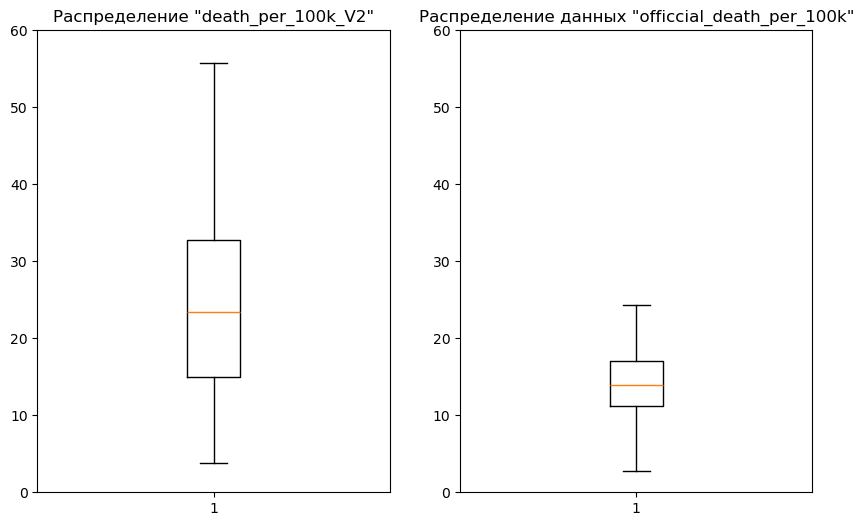

In [121]:
# Сравнение распредление данных официальной статистики и избытка смертности в V2
fig, ax = plt.subplots(1, 2, figsize=(10, 6))

ax[0].boxplot(vied_period['death_per_100k_V2'], label='death_per_100k_V2')
ax[0].set_title('Распределение "death_per_100k_V2"')
ax[0].set_ylim(bottom=0, top=60)

ax[1].boxplot(vied_period['officcial_death_per_100k'], label='officcial_death_per_100k')
ax[1].set_title('Распределение данных "officcial_death_per_100k"') 
ax[1].set_ylim(bottom=0, top=60)

plt.show()

# Матрица корреляции

In [76]:
print('Correlation with version 2')
print(vied_period[['officcial_death_per_100k', 'death_per_100k_V2']].corr())
print('-'*10)
print('Correlation with version 1')
print(vied_period[['calculated_death_per_100k', 'officcial_death_per_100k']].corr())

Correlation with version 2
                          officcial_death_per_100k  death_per_100k_V2
officcial_death_per_100k                  1.000000           0.522824
death_per_100k_V2                         0.522824           1.000000
----------
Correlation with version 1
                           calculated_death_per_100k  officcial_death_per_100k
calculated_death_per_100k                   1.000000                  0.528001
officcial_death_per_100k                    0.528001                  1.000000


# Построение линейной регрессии: сравнение V2 и V1 версий с официальными данными

In [77]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [78]:
len(vied_period['calculated_death_per_100k']), len(vied_period['officcial_death_per_100k'])

(23, 23)

In [79]:
def mse_scorer(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

# Данные для регрессии
X_v1 = covid_cummaulative_mortality[['officcial_death_per_100k']].values
y_v1 = covid_cummaulative_mortality['calculated_death_per_100k'].values

X_v2 = covid_cummaulative_mortality[['officcial_death_per_100k']].values
y_v2 = covid_cummaulative_mortality['death_per_100k_V2'].values

model = LinearRegression()

loo = LeaveOneOut()

mse_scores_v1 = -cross_val_score(model, X_v1, y_v1, cv=loo, scoring='neg_mean_squared_error')
print(f"V1 - Среднеквадратичная ошибка (LOO CV): {mse_scores_v1.mean():.4f} +/- {mse_scores_v1.std():.4f}")

mse_scores_v2 = -cross_val_score(model, X_v2, y_v2, cv=loo, scoring='neg_mean_squared_error')
print(f"V2 - Среднеквадратичная ошибка (LOO CV): {mse_scores_v2.mean():.4f} +/- {mse_scores_v2.std():.4f}")

model.fit(X_v1, y_v1)
print(f"\nКоэффициенты модели V1 (все данные): Coef = {model.coef_[0]:.4f}, Intercept = {model.intercept_:.4f}")

model.fit(X_v2, y_v2)
print(f"Коэффициенты модели V2 (все данные): Coef = {model.coef_[0]:.4f}, Intercept = {model.intercept_:.4f}")

V1 - Среднеквадратичная ошибка (LOO CV): 143.8848 +/- 203.6595
V2 - Среднеквадратичная ошибка (LOO CV): 162.5902 +/- 229.3718

Коэффициенты модели V1 (все данные): Coef = 2.2245, Intercept = -3.2156
Коэффициенты модели V2 (все данные): Coef = 2.3767, Intercept = -11.6002


In [80]:
def stamps_adder_v2(df):
    """
    Функция, которая для каждого месяца возвращает список штаммов,
    циркулировавших в этот период. В отличие от первой версии, не заменяет
    штаммы, а добавляет новые к уже существующим.
    """
    stamps = []
    
    if df['year'] == 2020:
        stamps.append('Hu-1')
        if df['month'] >= 3:
            stamps.append('Hu-1 D614G')
    elif df['year'] == 2021:
        stamps.append('Alpha')
        if df['month'] >= 6:
            stamps.append('Delta')
    else: 
        stamps.append('Omicron')
        if df['month'] <= 3:
            stamps.append('Delta') 
    
    return stamps

covid_stamps['stamps_list'] = covid_stamps.apply(stamps_adder_v2, axis=1)
print("Пример одновременной циркуляции штаммов:")
print(covid_stamps[['year', 'month', 'stamps_list']].head(10))

covid_stamps['stamps'] = covid_stamps.apply(stamps_adder, axis=1)



Пример одновременной циркуляции штаммов:
   year  month         stamps_list
0  2020      4  [Hu-1, Hu-1 D614G]
1  2020      5  [Hu-1, Hu-1 D614G]
2  2020      6  [Hu-1, Hu-1 D614G]
3  2020      7  [Hu-1, Hu-1 D614G]
4  2020      8  [Hu-1, Hu-1 D614G]
5  2020      9  [Hu-1, Hu-1 D614G]
6  2020     10  [Hu-1, Hu-1 D614G]
7  2020     11  [Hu-1, Hu-1 D614G]
8  2020     12  [Hu-1, Hu-1 D614G]
9  2021      1             [Alpha]


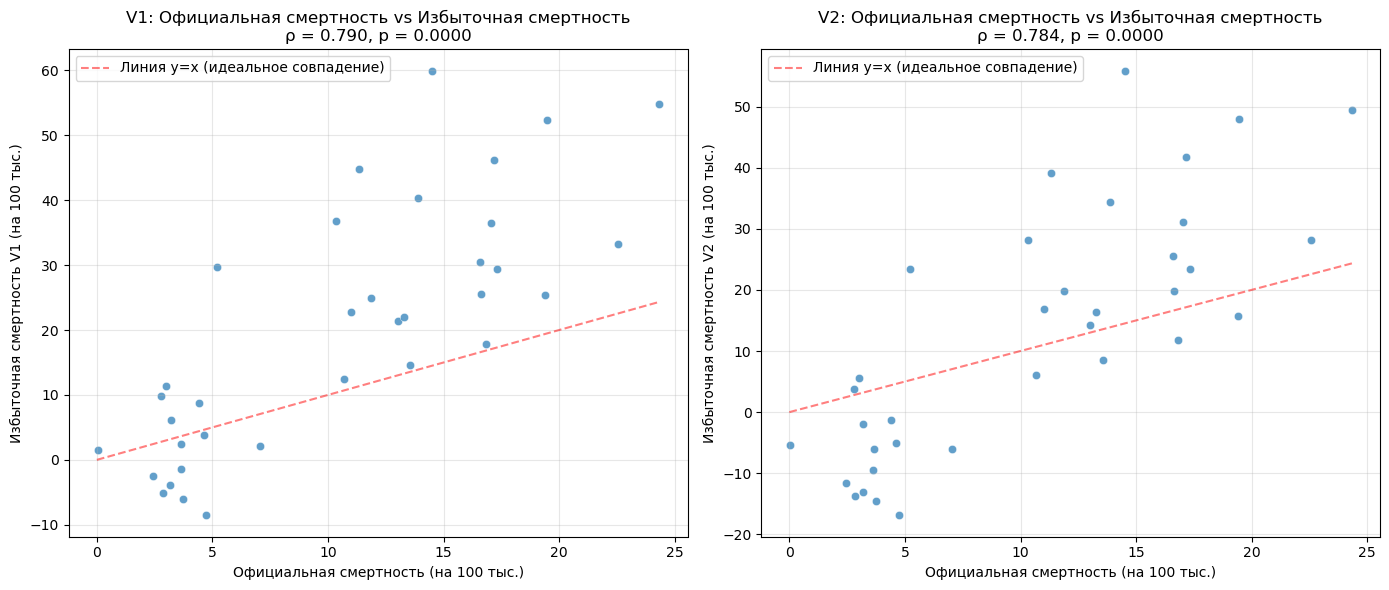

In [124]:
v1_data = covid_cummaulative_mortality[['officcial_death_per_100k', 'calculated_death_per_100k']].dropna()
v2_data = covid_cummaulative_mortality[['officcial_death_per_100k', 'death_per_100k_V2']].dropna()

corr_v1, p_v1 = spearmanr(v1_data['officcial_death_per_100k'], v1_data['calculated_death_per_100k'])
corr_v2, p_v2 = spearmanr(v2_data['officcial_death_per_100k'], v2_data['death_per_100k_V2'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
sns.scatterplot(data=v1_data, x='officcial_death_per_100k', y='calculated_death_per_100k', ax=ax1, alpha=0.7)
ax1.set_title(f'V1: Официальная смертность vs Избыточная смертность\nρ = {corr_v1:.3f}, p = {p_v1:.4f}')
ax1.set_xlabel('Официальная смертность (на 100 тыс.)')
ax1.set_ylabel('Избыточная смертность V1 (на 100 тыс.)')
ax1.grid(True, alpha=0.3)

x_range = np.linspace(0, v1_data['officcial_death_per_100k'].max(), 100)
ax1.plot(x_range, x_range, 'r--', alpha=0.5, label='Линия y=x (идеальное совпадение)')
ax1.legend()

ax2 = axes[1]
sns.scatterplot(data=v2_data, x='officcial_death_per_100k', y='death_per_100k_V2', ax=ax2, alpha=0.7)
ax2.set_title(f'V2: Официальная смертность vs Избыточная смертность\nρ = {corr_v2:.3f}, p = {p_v2:.4f}')
ax2.set_xlabel('Официальная смертность (на 100 тыс.)')
ax2.set_ylabel('Избыточная смертность V2 (на 100 тыс.)')
ax2.grid(True, alpha=0.3)
ax2.plot(x_range, x_range, 'r--', alpha=0.5, label='Линия y=x (идеальное совпадение)')
ax2.legend()

plt.tight_layout()
plt.show()

In [81]:
excess_mortality_v1 = covid_cummaulative_mortality['calculated_death_per_100k'].values
excess_mortality_v2 = covid_cummaulative_mortality['death_per_100k_V2'].values

pre_covid_deaths = []
for month in pre_covid_moscow_death_.iloc[:, 1:-1].columns:
    pre_covid_deaths.extend(pre_covid_moscow_death_[month].tolist())
pre_covid_deaths = np.array(pre_covid_deaths)

covid_deaths = []
for month in covid_moscow_death_.iloc[:, 1:-1].columns:
    covid_deaths.extend(covid_moscow_death_[month].tolist())
covid_deaths = np.array(covid_deaths)

covid_stamps['cfr_monthly'] = (covid_stamps['death_per_100k'] / covid_stamps['cases_per_100k']) * 100

cfr_by_stamp = [group['cfr_monthly'].values for name, group in covid_stamps.groupby('stamps')]

In [82]:
print("1. Сравнение методологий расчета избыточной смертности (V1 vs V2):")
print(f"   H0: Методологии V1 и V2 дают статистически одинаковые результаты.")
stat, p_value = mannwhitneyu(excess_mortality_v1, excess_mortality_v2, alternative='two-sided')
print(f"   Результат U-теста Манна-Уитни: statistic = {stat:.4f}, p-value = {p_value:.6f}")
if p_value < 0.05:
    print("   ВЫВОД: Отвергаем H0. Методологии дают статистически разные результаты (p < 0.05).")
else:
    print("  ВЫВОД: Нет оснований отвергнуть H0. Методологии статистически неразличимы.")
print("-" * 60)

print("\n2. Влияние пандемии на общую смертность (Pre-COVID vs COVID):")
print(f"   H0: Среднемесячная смертность в COVID-период не отличается от доковидного уровня.")
stat, p_value = mannwhitneyu(covid_deaths, pre_covid_deaths, alternative='greater')
print(f"   Результат U-теста Манна-Уитни (односторонний): statistic = {stat:.4f}, p-value = {p_value:.6f}")
if p_value < 0.05:
    print("   ВЫВОД: Отвергаем H0. Смертность в COVID-период статистически значимо выше доковидного уровня (p < 0.05).")
else:
    print("   ВЫВОД: Нет оснований отвергнуть H0. Смертность статистически не изменилась.")
print("-" * 60)

print("\n3. Сравнение летальности (CFR) между штаммами SARS-CoV-2:")
print(f"   H0: Показатель летальности (CFR) одинаков у всех штаммов.")
stat, p_value = kruskal(*cfr_by_stamp)
print(f"   Результат H-теста Крускала-Уоллиса: statistic = {stat:.4f}, p-value = {p_value:.6f}")
if p_value < 0.05:
    print("   ВЫВОД: Отвергаем H0. CFR статистически значимо различается между штаммами (p < 0.05).")
    print("   INFO: Для определения, какие именно штаммы различаются, необходим post-hoc анализ (например, Dunn test).")
else:
    print("   ВЫВОД: Нет оснований отвергнуть H0. CFR между штаммами статистически неразличим.")
print("-" * 60)


1. Сравнение методологий расчета избыточной смертности (V1 vs V2):
   H0: Методологии V1 и V2 дают статистически одинаковые результаты.
   Результат U-теста Манна-Уитни: statistic = 736.0000, p-value = 0.148523
  ВЫВОД: Нет оснований отвергнуть H0. Методологии статистически неразличимы.
------------------------------------------------------------

2. Влияние пандемии на общую смертность (Pre-COVID vs COVID):
   H0: Среднемесячная смертность в COVID-период не отличается от доковидного уровня.
   Результат U-теста Манна-Уитни (односторонний): statistic = 4065.0000, p-value = 0.000604
   ВЫВОД: Отвергаем H0. Смертность в COVID-период статистически значимо выше доковидного уровня (p < 0.05).
------------------------------------------------------------

3. Сравнение летальности (CFR) между штаммами SARS-CoV-2:
   H0: Показатель летальности (CFR) одинаков у всех штаммов.
   Результат H-теста Крускала-Уоллиса: statistic = 2.2993, p-value = 0.680896
   ВЫВОД: Нет оснований отвергнуть H0. CFR м

In [83]:
linear_model_v1 = vied_period[['officcial_death_per_100k', 'calculated_death_per_100k']]

X = linear_model_v1[['officcial_death_per_100k']]
y = linear_model_v1['calculated_death_per_100k']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("First version of data")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

First version of data
Mean Squared Error: 242.24345040260127
R-squared: -0.0966265077485382
Coefficients: [1.57374259]
Intercept: 6.87501254358207


In [84]:
linear_model_v2 = vied_period[['officcial_death_per_100k', 'death_per_100k_V2']]

X = linear_model_v2[['officcial_death_per_100k']]
y = linear_model_v2['death_per_100k_V2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Second version of data")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

Second version of data
Mean Squared Error: 260.70985720420896
R-squared: -0.09211264025424737
Coefficients: [1.60199195]
Intercept: 0.3980520658113065


# Работа с био частью

Создание таблицсмертности по штаммам в период пандемии в МСК

In [85]:
!pip install Biopython

In [86]:
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqUtils import gc_fraction
from Bio.SeqFeature import FeatureLocation

import re

In [87]:
def find_sequence_pattern(genome_file, pattern):
    """
    Поиск определенной последовательности в геноме
    """
    results = []

    # Чтение генома из файла
    for record in SeqIO.parse(genome_file, 'fasta'):
        sequence = str(record.seq).upper()
        pattern_upper = pattern.upper()

        # Поиск всех вхождений
        positions = []
        start = 0
        while True:
            pos = sequence.find(pattern_upper, start)
            if pos == -1:
                break
            positions.append(pos)
            start = pos + 1

        results.append({
            'record_id': record.id,
            'pattern': pattern,
            'positions': positions,
            'count': len(positions)
        })

    return results

# поиск паттернов
genome_file = 'genomic.fna'
pattern = 'ATG'
results = find_sequence_pattern(genome_file, pattern)
for result in results:
    print(f"В {result['record_id']} найдено {result['count']} вхождений '{result['pattern']}'")

В NC_045512.2 найдено 725 вхождений 'ATG'


In [88]:
def find_orfs(sequence, min_length=300):
    """
    Поиск открытых рамок считывания (ORF)
    """
    start_codon = 'ATG'
    stop_codons = ['TAA', 'TAG', 'TGA']

    orfs = []
    sequence = str(sequence).upper()

    for frame in range(3):
        for i in range(frame, len(sequence) - 2, 3):
            codon = sequence[i:i+3]

            if codon == start_codon:
                # Ищем стоп-кодон
                for j in range(i + 3, len(sequence) - 2, 3):
                    stop_codon = sequence[j:j+3]
                    if stop_codon in stop_codons:
                        orf_length = j + 3 - i
                        if orf_length >= min_length:
                            orfs.append({
                                'start': i,
                                'end': j + 3,
                                'length': orf_length,
                                'frame': frame + 1,
                                'sequence': sequence[i:j+3]
                            })
                        break

    return sorted(orfs, key=lambda x: x['length'], reverse=True)

for record in SeqIO.parse('genomic.fna', 'fasta'):
    orfs = find_orfs(record.seq, min_length=100)
    print(f'В {record.id} найдено {len(orfs)} ORF длиной > 100 п.н.')

В NC_045512.2 найдено 269 ORF длиной > 100 п.н.


In [89]:
# Создание таблицы приведенной смертсноти и заболеваемости путем джоина двух таблиц по мск
covid_stamps = vied_period[['year', 'month', 'death_per_100k_V2']]
covid_stamps.columns = ['year', 'month', 'death_per_100k']
covid_stamps = covid_stamps.merge(moscow[['year', 'month', 'cases', 'population']], on=['year', 'month'], how='left')
covid_stamps['cases_per_100k'] = covid_stamps.apply(lambda x: x['cases'] / x['population'] * 100000, axis=1)
covid_stamps.drop(['cases', 'population'], axis=1, inplace=True)
covid_stamps.head(5)

,year,month,death_per_100k,cases_per_100k
0,2020,4,8.51881,986.519956
1,2020,5,39.10559,367.360782
2,2020,6,23.36655,151.790503
3,2020,7,3.78333,166.004102
4,2020,8,5.60725,217.952358


In [90]:
def stamps_adder(df):
  """
  Функция на вход получает датафрейм, затем по датам проставляем штаммы, которые
  ходили в популяции Мск в указанный месяц / год
  """
  if df['year'] == 2020:
    if df['month'] in [3, 4]:
      return 'Hu-1'
    else:
      return 'Hu-1 D614G'

  if df['year'] == 2021:
    if df['month'] in [1, 2, 4, 5, 6]:
      return 'Alpha'
    else:
      return 'Delta'

  else:
    return 'Omicron'


In [91]:
covid_stamps['stamps'] = covid_stamps.apply(stamps_adder, axis=1)
covid_stamps.head(10)

,year,month,death_per_100k,cases_per_100k,stamps
0,2020,4,8.51881,986.519956,Hu-1
1,2020,5,39.10559,367.360782,Hu-1 D614G
2,2020,6,23.36655,151.790503,Hu-1 D614G
3,2020,7,3.78333,166.004102,Hu-1 D614G
4,2020,8,5.60725,217.952358,Hu-1 D614G
5,2020,9,6.09684,954.637956,Hu-1 D614G
6,2020,10,19.86163,1446.545196,Hu-1 D614G
7,2020,11,31.09981,1577.867171,Hu-1 D614G
8,2020,12,41.70015,1026.202871,Hu-1 D614G
9,2021,1,34.43816,441.856974,Alpha


In [92]:
# Сводная таблица по среднему значению смертности и заболеваемости с группировкой по штаммах
stamps_info = (covid_stamps[['stamps', 'death_per_100k', 'cases_per_100k']]
 .groupby('stamps')
 .mean()
 .reset_index())
stamps_info

,stamps,death_per_100k,cases_per_100k
0,Alpha,28.118032,804.161201
1,Delta,29.049633,961.815206
2,Hu-1,8.518810,986.519956
3,Hu-1 D614G,21.327644,738.545118
4,Omicron,21.973055,1741.747983


In [93]:
# За базовое значение берем штамм HU-1
hu1_death = stamps_info[stamps_info['stamps'] == 'Hu-1']['death_per_100k'].iloc[0]
hu1_cases = stamps_info[stamps_info['stamps'] == 'Hu-1']['cases_per_100k'].iloc[0]

# Летальность (CFR)
stamps_info['cfr_percent'] = (stamps_info['death_per_100k'] / stamps_info['cases_per_100k']) * 100
hu1_cfr = stamps_info[stamps_info['stamps'] == 'Hu-1']['cfr_percent'].iloc[0]
stamps_info['cfr_coef'] = stamps_info['cfr_percent'] / hu1_cfr

# Коэффициенты смертности и распространения
stamps_info['death_coef'] = stamps_info['death_per_100k'] / hu1_death
stamps_info['spread_coef'] = stamps_info['cases_per_100k'] / hu1_cases

# Показатель опасности = death_coef * 0.7 + spread_coef * 0.3
stamps_info['composite_danger'] = stamps_info['death_coef'] * 0.7 + stamps_info['spread_coef'] * 0.3

# Bruden_coef = death_per_100k * log(cases_per_100k)
stamps_info['total_burden'] = stamps_info['death_per_100k'] * np.log(stamps_info['cases_per_100k'])
hu1_burden = stamps_info[stamps_info['stamps'] == 'Hu-1']['total_burden'].iloc[0]
stamps_info['burden_coef'] = stamps_info['total_burden'] / hu1_burden

stamps_info

,stamps,death_per_100k,cases_per_100k,cfr_percent,cfr_coef,death_coef,spread_coef,composite_danger,total_burden,burden_coef
0,Alpha,28.118032,804.161201,3.496567,4.049196,3.300700,0.815149,2.555034,188.104003,3.202848
1,Delta,29.049633,961.815206,3.020293,3.497647,3.410058,0.974958,2.679528,199.536767,3.397513
2,Hu-1,8.518810,986.519956,0.863521,1.000000,1.000000,1.000000,1.000000,58.730240,1.000000
3,Hu-1 D614G,21.327644,738.545118,2.887792,3.344204,2.503594,0.748637,1.977107,140.862309,2.398463
4,Omicron,21.973055,1741.747983,1.261552,1.460939,2.579357,1.765548,2.335214,163.977098,2.792039


In [94]:
stamps_coefficients = stamps_info[['stamps', 'death_coef', 'spread_coef', 'composite_danger']].round(2)
stamps_coefficients

,stamps,death_coef,spread_coef,composite_danger
0,Alpha,3.30,0.82,2.56
1,Delta,3.41,0.97,2.68
2,Hu-1,1.00,1.00,1.00
3,Hu-1 D614G,2.50,0.75,1.98
4,Omicron,2.58,1.77,2.34


In [95]:
def normalize_column(column):
    """
    Функкция для проведение линейного маштабирования Min-Max Normalization
    Считает манимальное и максимальное значение в каждой колонке -> приводит остальные
    значения отросительно минимого и максимума
    """
    min_val = column.min()
    max_val = column.max()
    return 1 + (column - min_val) * 9 / (max_val - min_val)

def norm_danger(df):
  """
  Расчет коэффициента опасности после нормализации остальных кожффициентов
  """
  return df['death_coef']*0.7 + df['spread_coef'] * 0.3

In [96]:
# Создаем отдельный датафрем для номрализированных значений
stamps_coefficients_norm = stamps_coefficients.copy()
numeric_columns = ['death_coef', 'spread_coef']

stamps_coefficients_norm[numeric_columns] = stamps_coefficients_norm[numeric_columns].apply(normalize_column)
stamps_coefficients_norm['composite_danger'] = stamps_coefficients_norm.apply(norm_danger, axis=1)

stamps_coefficients_norm.round(2)

,stamps,death_coef,spread_coef,composite_danger
0,Alpha,9.59,1.62,7.20
1,Delta,10.00,2.94,7.88
2,Hu-1,1.00,3.21,1.66
3,Hu-1 D614G,6.60,1.00,4.92
4,Omicron,6.90,10.00,7.83


In [97]:
# Коэффициентов мутаций (заданы вручную относительно литературных данных)
mutation_impact = {
    'Alpha': {
        'transmission_impact': {
            'N501Y': 0.5,
            'P681H': 0.3
        },
        'severity_impact': {
            'N501Y': 0.6,
            'P681H': 0.4
        }
    },

    'Delta': {
        'transmission_impact': {
            'L452R': 0.4,
            'P681R': 0.3,
            'T478K': 0.2,
            'E484Q': 0.1
          },
        'severity_impact': {
            'L452R': 0.3,
            'P681R': 0.4,
            'T478K': 0.2,
            'E484Q': 0.1
          }
    },

    'Omicron': {
        'transmission_impact': {
            'S371L': 0.15, 'S373P': 0.1, 'S375F': 0.1,
            'K417N': 0.2, 'N440K': 0.15, 'G446S': 0.1,
        },
        'severity_impact': {
            'S371L': 0.05, 'S373P': 0.05, 'S375F': 0.05,
            'K417N': 0.1, 'N440K': 0.08, 'G446S': 0.07,
        }
    },

    'Hu-1 D614G': {
        'transmission_impact': {
            'D614G': 0.7,
            'A222V': 0.3
        },
        'severity_impact': {
            'D614G': 0.5,
            'A222V': 0.5
        }
    }
}

In [98]:
def calculate_mutation_contributions(stamps_coefficients, mutation_impact):
    """
    Вычисление абсолютного вклада каждой мутации в изменение смертности и заболеваемости
    относительно базового штамма Hu-1.
    """
    contributions = []

    for stamp in mutation_impact.keys():
        # Находим базовые значения (Hu-1)
        base_death = stamps_coefficients[stamps_coefficients['stamps'] == 'Hu-1']['death_coef'].values[0]
        base_spread = stamps_coefficients[stamps_coefficients['stamps'] == 'Hu-1']['spread_coef'].values[0]

        # Текущие значения штамма
        current_death = stamps_coefficients[stamps_coefficients['stamps'] == stamp]['death_coef'].values[0]
        current_spread = stamps_coefficients[stamps_coefficients['stamps'] == stamp]['spread_coef'].values[0]

        # Общий прирост относительно базового штамма
        death_increase = current_death - base_death
        spread_increase = current_spread - base_spread

        # Распределяем прирост по мутациям
        total_severity_impact = sum(mutation_impact[stamp]['severity_impact'].values())
        total_transmission_impact = sum(mutation_impact[stamp]['transmission_impact'].values())

        for mutation in mutation_impact[stamp]['severity_impact']:
            severity_share = mutation_impact[stamp]['severity_impact'][mutation] / total_severity_impact
            transmission_share = mutation_impact[stamp]['transmission_impact'][mutation] / total_transmission_impact

            death_contribution = death_increase * severity_share
            spread_contribution = spread_increase * transmission_share

            contributions.append({
                'stamp': stamp,
                'mutation': mutation,
                'death_contribution': death_contribution,
                'spread_contribution': spread_contribution,
                'composite_contribution': death_contribution * 0.7 + spread_contribution * 0.3
            })

    return pd.DataFrame(contributions)

mutation_contributions = calculate_mutation_contributions(stamps_coefficients, mutation_impact)
mutation_contributions

,stamp,mutation,death_contribution,spread_contribution,composite_contribution
0,Alpha,N501Y,1.3800,-0.112500,0.932250
1,Alpha,P681H,0.9200,-0.067500,0.623750
2,Delta,L452R,0.7230,-0.012000,0.502500
3,Delta,P681R,0.9640,-0.009000,0.672100
4,Delta,T478K,0.4820,-0.006000,0.335600
5,Delta,E484Q,0.2410,-0.003000,0.167800
6,Omicron,S371L,0.1975,0.144375,0.181562
7,Omicron,S373P,0.1975,0.096250,0.167125
8,Omicron,S375F,0.1975,0.096250,0.167125
9,Omicron,K417N,0.3950,0.192500,0.334250


In [99]:
def create_mutation_danger_assessment(mutation_contributions):
    """
    Преобразование данных о вкладе мутаций в унифицированную систему оценки по мутациям:
      - Нормализованные показатели (от 0 до 1)
      - Категорию опасности
      - Возможность сравнения между собой
    """

    # Агрегация по мутациям (если мутация встречается в нескольких штаммах)
    mutation_danger = mutation_contributions.groupby('mutation').agg({
        'death_contribution': 'mean',
        'spread_contribution': 'mean',
        'composite_contribution': 'mean'
    }).reset_index()

    # Нормализуем вклады от 0 до 1
    for col in ['death_contribution', 'spread_contribution', 'composite_contribution']:
        mutation_danger[f'{col}_normalized'] = (
            mutation_danger[col] - mutation_danger[col].min()
        ) / (mutation_danger[col].max() - mutation_danger[col].min())

    # Создаем категории опасности
    def get_danger_category(composite_score):
        if composite_score >= 0.7:
            return 'КРИТИЧЕСКАЯ ОПАСНОСТЬ'
        elif composite_score >= 0.5:
            return 'ВЫСОКАЯ ОПАСНОСТЬ'
        elif composite_score >= 0.3:
            return 'СРЕДНЯЯ ОПАСНОСТЬ'
        else:
            return 'НИЗКАЯ ОПАСНОСТЬ'

    mutation_danger['danger_category'] = mutation_danger['composite_contribution_normalized'].apply(get_danger_category)

    return mutation_danger

mutation_danger = create_mutation_danger_assessment(mutation_contributions)
mutation_danger

,mutation,death_contribution,spread_contribution,composite_contribution,death_contribution_normalized,spread_contribution_normalized,composite_contribution_normalized,danger_category
0,A222V,0.7500,-0.075000,0.502500,0.467230,0.272109,0.438327,СРЕДНЯЯ ОПАСНОСТЬ
1,D614G,0.7500,-0.175000,0.472500,0.467230,0.000000,0.399118,СРЕДНЯЯ ОПАСНОСТЬ
2,E484Q,0.2410,-0.003000,0.167800,0.036786,0.468027,0.000882,НИЗКАЯ ОПАСНОСТЬ
3,G446S,0.2765,0.096250,0.222425,0.066808,0.738095,0.072276,НИЗКАЯ ОПАСНОСТЬ
4,K417N,0.3950,0.192500,0.334250,0.167019,1.000000,0.218428,НИЗКАЯ ОПАСНОСТЬ
5,L452R,0.7230,-0.012000,0.502500,0.444397,0.443537,0.438327,СРЕДНЯЯ ОПАСНОСТЬ
6,N440K,0.3160,0.144375,0.264512,0.100211,0.869048,0.127283,НИЗКАЯ ОПАСНОСТЬ
7,N501Y,1.3800,-0.112500,0.932250,1.000000,0.170068,1.000000,КРИТИЧЕСКАЯ ОПАСНОСТЬ
8,P681H,0.9200,-0.067500,0.623750,0.610994,0.292517,0.596798,ВЫСОКАЯ ОПАСНОСТЬ
9,P681R,0.9640,-0.009000,0.672100,0.648203,0.451701,0.659990,ВЫСОКАЯ ОПАСНОСТЬ


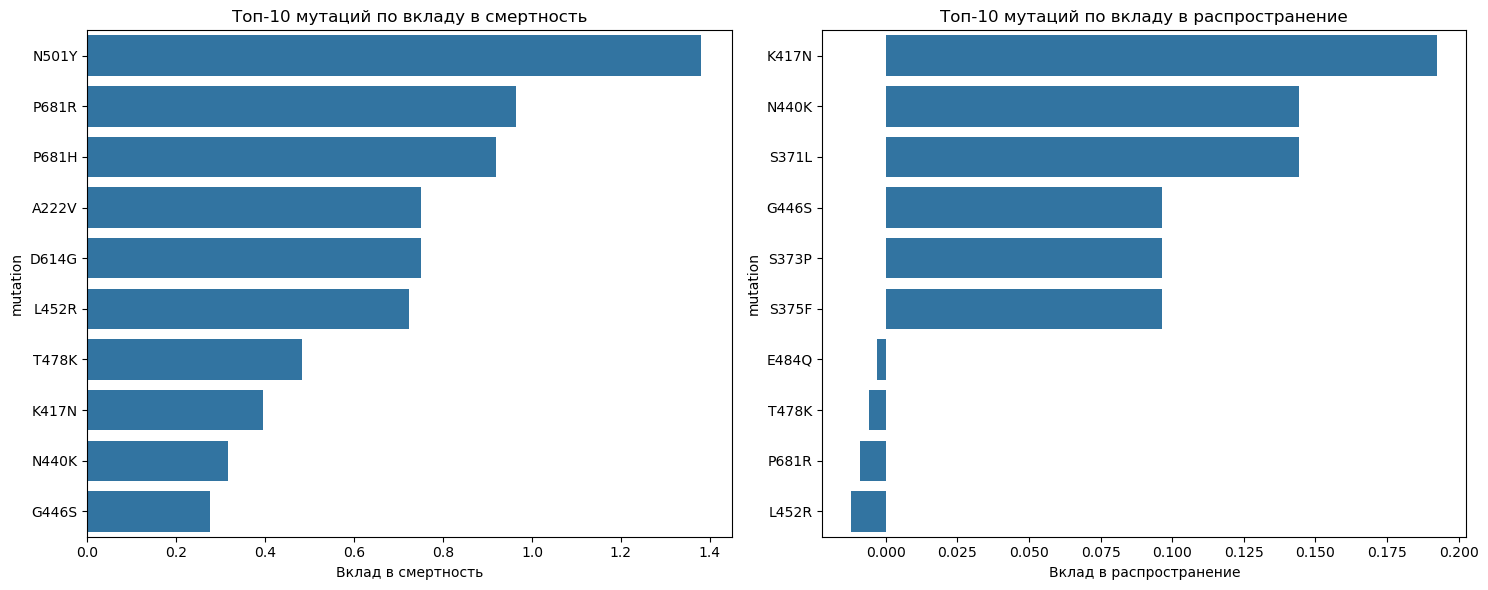

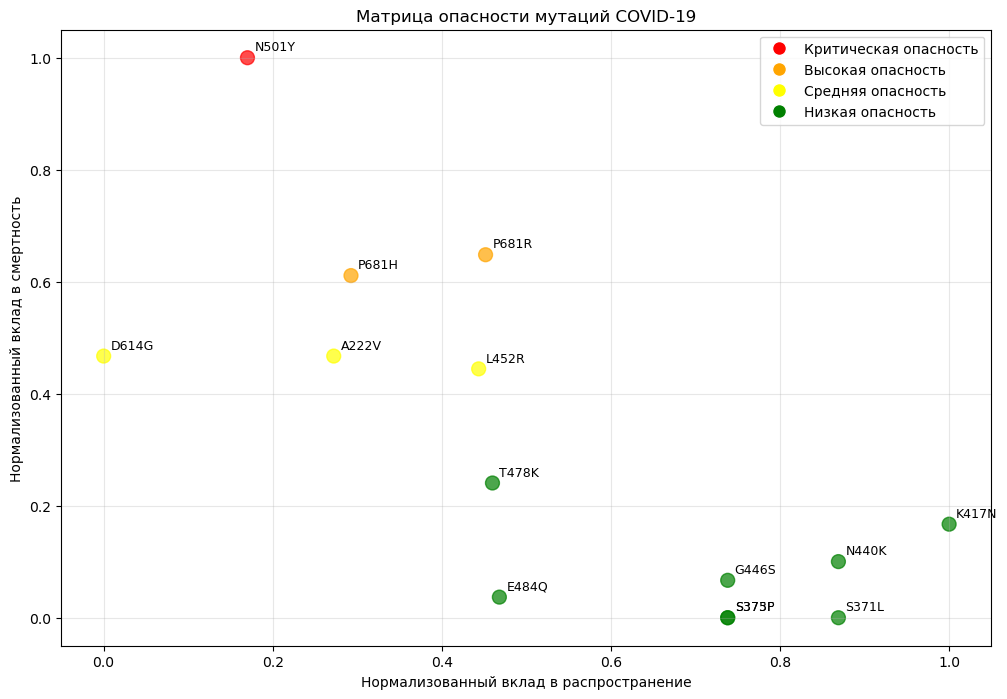

In [100]:
def visualize_mutation_impact(mutation_danger):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    death_data = mutation_danger.nlargest(10, 'death_contribution')
    sns.barplot(data=death_data, x='death_contribution', y='mutation', ax=ax1)
    ax1.set_title('Топ-10 мутаций по вкладу в смертность')
    ax1.set_xlabel('Вклад в смертность')

    spread_data = mutation_danger.nlargest(10, 'spread_contribution')
    sns.barplot(data=spread_data, x='spread_contribution', y='mutation', ax=ax2)
    ax2.set_title('Топ-10 мутаций по вкладу в распространение')
    ax2.set_xlabel('Вклад в распространение')
    plt.savefig('2.png')
    plt.tight_layout()
    plt.show()

def create_danger_matrix(mutation_danger):
    pivot_data = mutation_danger[['mutation', 'death_contribution_normalized',
                                'spread_contribution_normalized', 'danger_category']]
    pivot_data = pivot_data.sort_values('death_contribution_normalized', ascending=False)

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(
        pivot_data['spread_contribution_normalized'],
        pivot_data['death_contribution_normalized'],
        c=[{'НИЗКАЯ ОПАСНОСТЬ': 'green', 'СРЕДНЯЯ ОПАСНОСТЬ': 'yellow',
            'ВЫСОКАЯ ОПАСНОСТЬ': 'orange', 'КРИТИЧЕСКАЯ ОПАСНОСТЬ': 'red'}[cat]
           for cat in pivot_data['danger_category']],
        s=100, alpha=0.7
    )

    for i, row in pivot_data.iterrows():
        plt.annotate(row['mutation'],
                    (row['spread_contribution_normalized'], row['death_contribution_normalized']),
                    xytext=(5, 5), textcoords='offset points', fontsize=9)

    plt.xlabel('Нормализованный вклад в распространение')
    plt.ylabel('Нормализованный вклад в смертность')
    plt.title('Матрица опасности мутаций COVID-19')
    plt.grid(True, alpha=0.3)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Критическая опасность'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=10, label='Высокая опасность'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', markersize=10, label='Средняя опасность'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Низкая опасность')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.savefig('3.png')
    plt.show()

visualize_mutation_impact(mutation_danger)
create_danger_matrix(mutation_danger)